In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.special import logsumexp
import pickle
import json
import os
import time
from plotting_functions import plot_method_comparison, plot_gillespie_nmc_comparison
from saving_experiments import save_samples, load_samples, save_samples_summary
from main_code import run_diffusion_experiment, add_gillespie_reverse, add_tau_leap_reverse
from add_methods_utils import add_methods_to_lightweight_file, add_method_to_lightweight

In [18]:
# Define random masking methods
random_masking_methods = []

# Test different tau_c values
for tau_c in [1, 0.6, 0.4, 0.2]:
    # With reverse correction (apply_reverse=True)
    random_masking_methods.append({
        'type': 'tau_leap',
        'tau': 0.4,
        'corrector': True,
        'corrector_method': 'random_masking',
        'corrector_start': 1.0,
        'corrector_hyperparameters': {
            'n_corr': 1,
            'tau_c': tau_c,
            'apply_reverse': True
        }
    })
    
    # Forward only (apply_reverse=False)
    random_masking_methods.append({
        'type': 'tau_leap',
        'tau': 0.4,
        'corrector': True,
        'corrector_method': 'random_masking',
        'corrector_start': 1.0,
        'corrector_hyperparameters': {
            'n_corr': 1,
            'tau_c': tau_c,
            'apply_reverse': False
        }
    })

# Add them to the file
print("Adding random masking methods to gillespie_nmc_300000.pkl...")
results = add_methods_to_lightweight_file(
    'gillespie_nmc_300000.pkl',
    random_masking_methods
)

print(f"\n✓ Added {len(results['methods_added'])} random masking methods!")
print("Methods added:")
for method in results['methods_added']:
    print(f"  - {method}")

# Show breakdown
print("\nBreakdown:")
with_reverse = [m for m in results['methods_added'] if 'fwd_only' not in m]
fwd_only = [m for m in results['methods_added'] if 'fwd_only' in m]
print(f"  With reverse correction: {len(with_reverse)}")
print(f"  Forward only: {len(fwd_only)}")

Adding random masking methods to gillespie_nmc_300000.pkl...
ADDING METHODS TO LIGHTWEIGHT SAVE

Loading: gillespie_nmc_300000.pkl
Samples loaded (LIGHTWEIGHT - PMFs) from: gillespie_nmc_300000.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 11 methods
  - n_mc: 300000, N: 10, L: 3
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoint_formula', 'n_checkpoints', 'methods', 'timing', 'date', 'notes']
✓ Lightweight format confirmed

Parameters: N=10, L=3, beta=5.0, T=3.5, n_mc=300000
Existing methods (11): ['gillespie', 'tau_leap_0.1', 'tau_leap_0.01', 'tau_leap_0.008', 'tau_leap_0.005', 'tau_leap_1.5', 'tau_leap_1', 'tau_leap_0.5', 'tau_leap_0.4', 'tau_leap_0.3', 'tau_leap_0.2']

Adding 8 new methods...

[1/8] Adding: tau=0.4, random_masking
Running tau-leaping (tau=0.4) reverse process...
  With corrector: random_masking, start=1.0
  Corrector hyperparameters: {'n_corr': 1, 'tau_c': 1, 'apply_reverse': True}
  Tau-leap particle 0/300000
  Tau-leap particl

Samples loaded (LIGHTWEIGHT - PMFs) from: gillespie_nmc_300000.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 19 methods
  - n_mc: 300000, N: 10, L: 3
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoint_formula', 'n_checkpoints', 'methods', 'timing', 'date', 'notes']
Computing Hellinger distances from joint PMFs...

Generating plot for methods: ['gillespie', 'tau_leap_0.4', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2']
Time range: [0.000, 3.500]
Plot saved to: random_masking_tauc_comparison.png


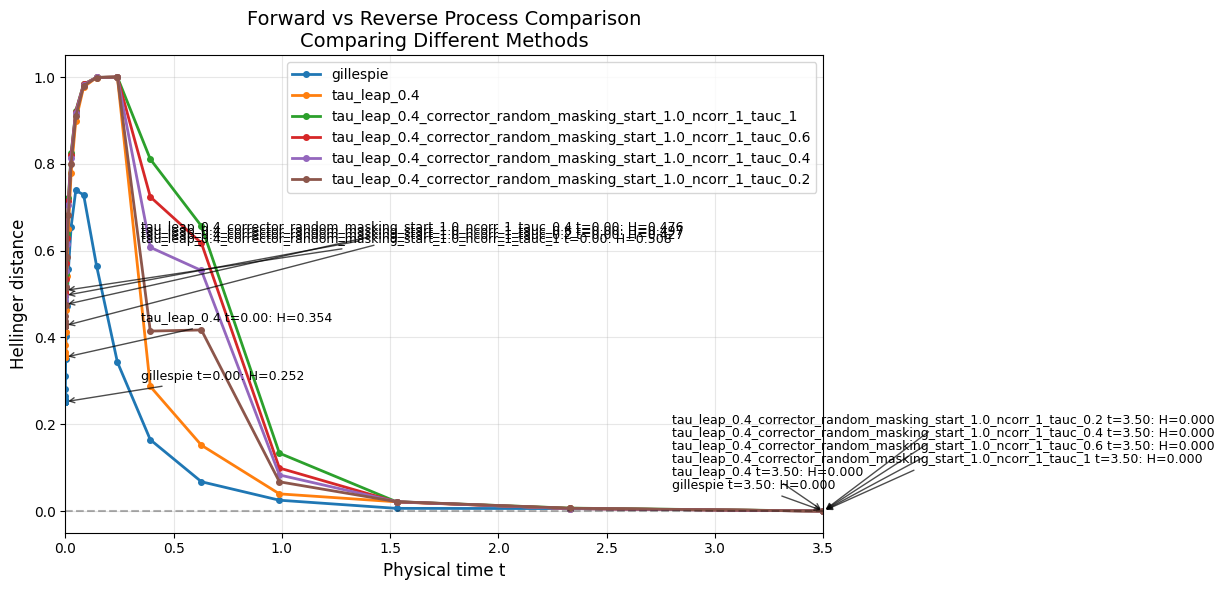

In [20]:
data, metadata = load_samples('gillespie_nmc_300000.pkl')

# Plot all methods
a = plot_method_comparison(
    data,
    methods=['gillespie', 'tau_leap_0.4','tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2' ],  # None = plot all methods
    filename='random_masking_tauc_comparison.png',
    show_annotations=True, return_distances=True
)

Samples loaded (LIGHTWEIGHT - PMFs) from: gillespie_nmc_300000.pkl
  - Forward PMFs: 31 checkpoints
  - Reverse PMFs: 19 methods
  - n_mc: 300000, N: 10, L: 3
  - User metadata: ['N', 'L', 'r', 'beta', 'T', 'n_mc', 'w', 'mu', 'checkpoint_formula', 'n_checkpoints', 'methods', 'timing', 'date', 'notes']
Computing Hellinger distances from joint PMFs...

Generating plot for methods: ['gillespie', 'tau_leap_0.4', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2_fwd_only']
Time range: [0.000, 3.500]
Plot saved to: random_masking_tauc_comparison_fwd_only.png


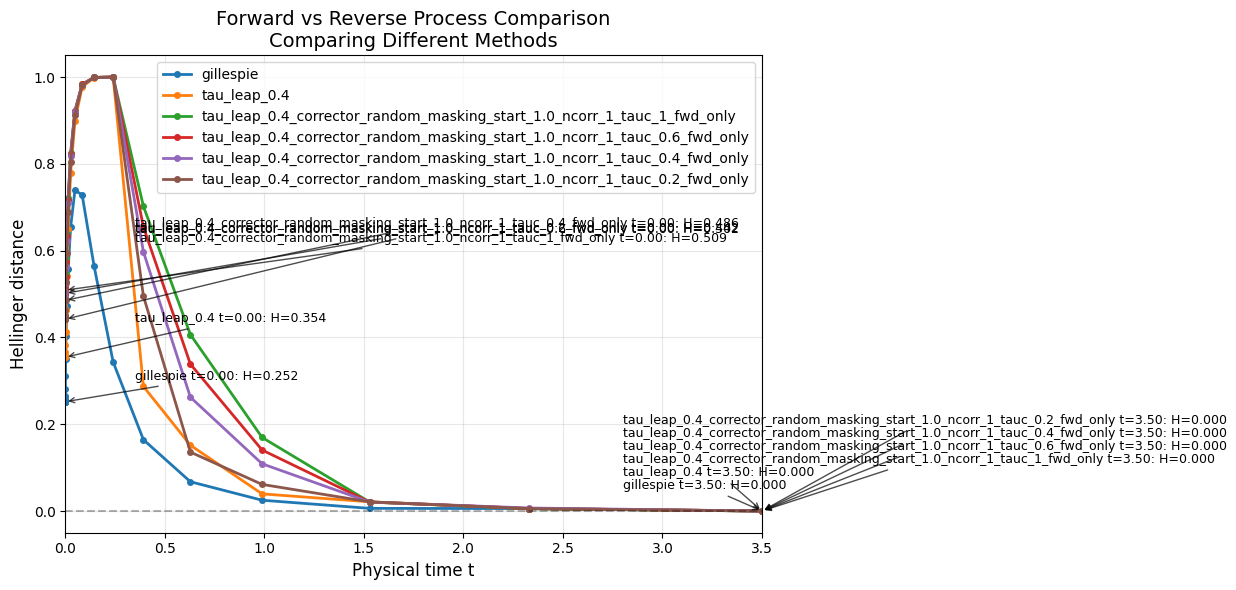

In [24]:
data, metadata = load_samples('gillespie_nmc_300000.pkl')

# Plot all methods
b = plot_method_comparison(
    data,
    methods=['gillespie', 'tau_leap_0.4', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4_fwd_only', 'tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2_fwd_only' ],  # None = plot all methods
    filename='random_masking_tauc_comparison_fwd_only.png',
    show_annotations=True,
    return_distances=True
)

In [25]:
print(f"gillespie: {b['gillespie'][0.0]:.2f}")
print(f"tau_leap_0.4: {b['tau_leap_0.4'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_1_fwd_only': {b['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1_fwd_only'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.6_fwd_only': {b['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6_fwd_only'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.4_fwd_only': {b['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4_fwd_only'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.2_fwd_only': {b['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2_fwd_only'][0.0]:.2f}")

gillespie: 0.25
tau_leap_0.4: 0.35
'tau_leap_0.4_tauc_1_fwd_only': 0.51
'tau_leap_0.4_tauc_0.6_fwd_only': 0.50
'tau_leap_0.4_tauc_0.4_fwd_only': 0.49
'tau_leap_0.4_tauc_0.2_fwd_only': 0.44


In [23]:
print(f"gillespie: {a['gillespie'][0.0]:.2f}")
print(f"tau_leap_0.4: {a['tau_leap_0.4'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_1': {a['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_1'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.6': {a['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.6'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.4': {a['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.4'][0.0]:.2f}")
print(f"'tau_leap_0.4_tauc_0.2': {a['tau_leap_0.4_corrector_random_masking_start_1.0_ncorr_1_tauc_0.2'][0.0]:.2f}")

gillespie: 0.25
tau_leap_0.4: 0.35
'tau_leap_0.4_tauc_1': 0.51
'tau_leap_0.4_tauc_0.6': 0.50
'tau_leap_0.4_tauc_0.4': 0.48
'tau_leap_0.4_tauc_0.2': 0.43
